<a href="https://colab.research.google.com/github/yulia3006/ml-basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [ ]:
%matplotlib inline
import pandas as pd
pd.__version__

'2.2.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [ ]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1) Выведите последние 10 элеметнов датасета

In [ ]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [ ]:
df.shape

(32561, 15)

3) Какие типы данных у элементов этого датасета?

In [ ]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


4) Какие признаки имеют пропуски?

In [ ]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ: не все участники опроса указали полные данные о себе, может затруднялись ответить или хотели вернуться к вопросу позже, но забыли это сделать



6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [ ]:
df.workclass.value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


7) Какой средний возраст женщин и мужчин?

In [ ]:
df.groupby('sex')['age'].mean()

,age
sex,
Female,36.858230
Male,39.433547


8) Постройте гистограмму(bar) распределения образования людей (education)

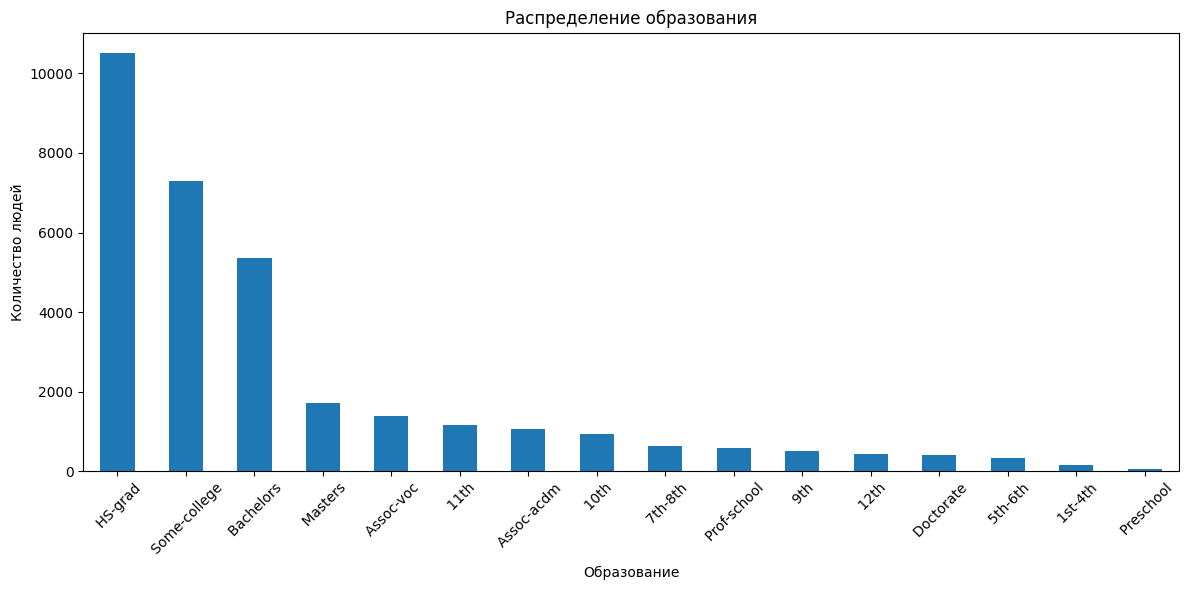

In [ ]:
plt.figure(figsize=(12, 6))
df['education'].value_counts().plot(kind='bar')
plt.title('Распределение образования')
plt.xlabel('Образование')
plt.ylabel('Количество людей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [ ]:
df.groupby('income')['age'].agg(['mean', 'std'])

,mean,std
income,,
<=50K,36.783738,14.020088
>50K,44.249841,10.519028


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [ ]:
higher_education = [' Bachelors', ' Prof-school', ' Assoc-acdm', ' Assoc-voc', ' Masters', ' Doctorate']
high_income = df[df['income'] == ' >50K']
has_higher_ed = high_income['education'].isin(higher_education)

print(f"Доля с высшим образованием среди >50K: {has_higher_ed.mean():.2%}")
print(f"Количество людей без высшего образования с доходом >50K: {(~has_higher_ed).sum()}")


Доля с высшим образованием среди >50K: 57.84%
Количество людей без высшего образования с доходом >50K: 3306


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [ ]:
# Фильтруем только мужчин
men = df[df['sex'] == ' Male'].copy()

# Разделяем на женатых и нет
married = men[men['marital.status'].str.startswith(' Married')]
single = men[~men['marital.status'].str.startswith(' Married')]

# Считаем долю зарабатывающих >50K
married_high = (married['income'] == ' >50K').mean()
single_high = (single['income'] == ' >50K').mean()

print(f"Доля женатых мужчин с доходом >50K: {married_high:.2%}")
print(f"Доля холостых мужчин с доходом >50K: {single_high:.2%}")

if married_high > single_high:
    print("Больше доля среди женатых мужчин")
else:
    print("Больше доля среди холостых мужчин")

Доля женатых мужчин с доходом >50K: 44.05%
Доля холостых мужчин с доходом >50K: 8.45%
Больше доля среди женатых мужчин


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



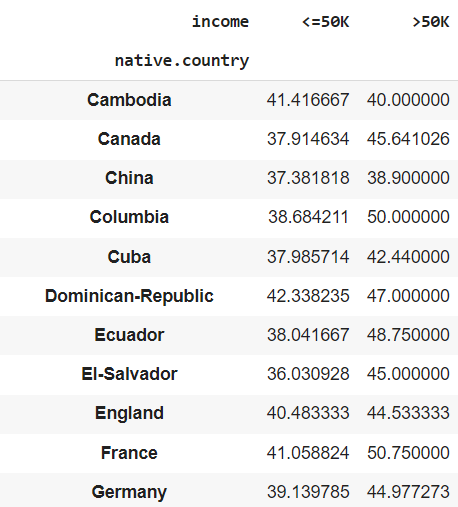

In [ ]:
pivot_table_res = df.pivot_table(
    values="hours.per.week",
    index="native.country",
    columns="income",
    aggfunc="mean"
)

display(pivot_table_res)

income,<=50K,>50K
native.country,,
Cambodia,41.416667,40.000000
Canada,37.914634,45.641026
China,37.381818,38.900000
Columbia,38.684211,50.000000
Cuba,37.985714,42.440000
Dominican-Republic,42.338235,47.000000
Ecuador,38.041667,48.750000
El-Salvador,36.030928,45.000000
England,40.483333,44.533333


13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

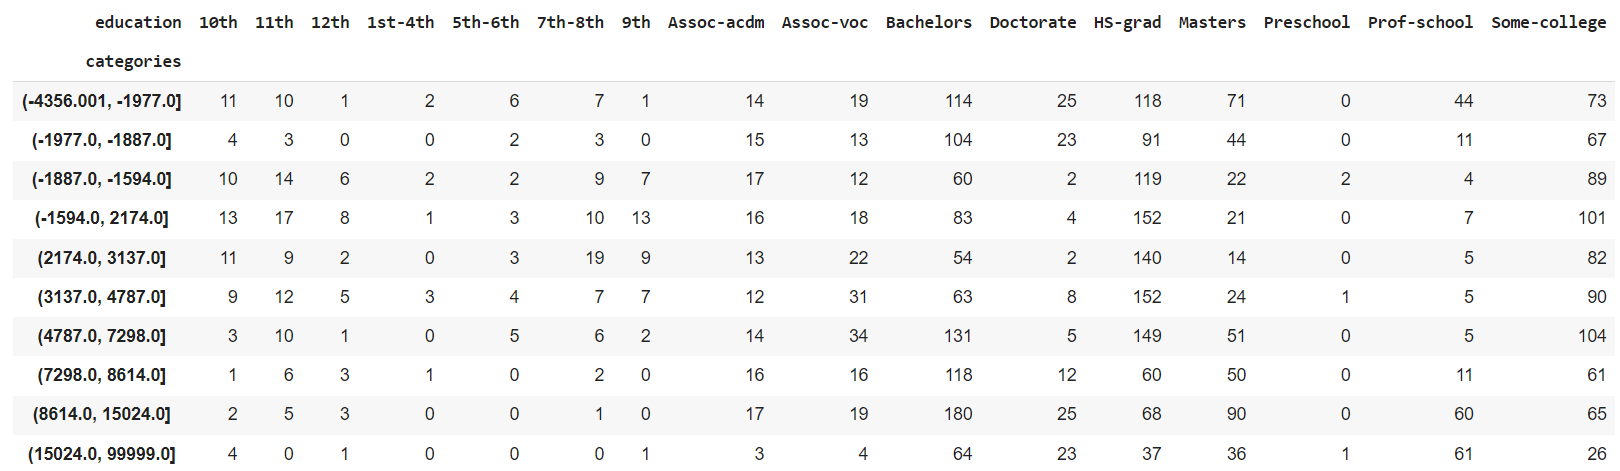

In [ ]:

summary_table = pd.DataFrame(df['education'].copy())
summary_table['capital.diff'] = df['capital.gain'] - df['capital.loss']
summary_table = summary_table[summary_table['capital.diff'] != 0]
summary_table['categories'] = pd.qcut(
    summary_table["capital.diff"],
    q=10,
    duplicates='drop'
)
pivot_table = summary_table.pivot_table(
    index="categories",
    columns="education",
    aggfunc="size",
    fill_value=0
)

display(pivot_table)

/tmp/ipykernel_247/1327705019.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = summary_table.pivot_table(


education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
categories,,,,,,,,,,,,,,,,
"(-4356.001, -1977.0]",11,10,1,2,6,7,1,14,19,114,25,118,71,0,44,73
"(-1977.0, -1887.0]",4,3,0,0,2,3,0,15,13,104,23,91,44,0,11,67
"(-1887.0, -1594.0]",10,14,6,2,2,9,7,17,12,60,2,119,22,2,4,89
"(-1594.0, 2174.0]",13,17,8,1,3,10,13,16,18,83,4,152,21,0,7,101
"(2174.0, 3137.0]",11,9,2,0,3,19,9,13,22,54,2,140,14,0,5,82
"(3137.0, 4787.0]",9,12,5,3,4,7,7,12,31,63,8,152,24,1,5,90
"(4787.0, 7298.0]",3,10,1,0,5,6,2,14,34,131,5,149,51,0,5,104
"(7298.0, 8614.0]",1,6,3,1,0,2,0,16,16,118,12,60,50,0,11,61
"(8614.0, 15024.0]",2,5,3,0,0,1,0,17,19,180,25,68,90,0,60,65


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [ ]:
women = df[df['sex'] == ' Female']
country_income = women.groupby('native.country')['income'].apply(lambda x: (x == ' >50K').mean()).sort_values(ascending=False)

print("Топ-10 стран по доле женщин с доходом >50K:")
print(country_income.head(10))


Топ-10 стран по доле женщин с доходом >50K:
native.country
Yugoslavia    0.333333
Taiwan        0.266667
France        0.250000
Iran          0.250000
Japan         0.250000
Italy         0.238095
China         0.238095
Canada        0.230769
Greece        0.200000
Scotland      0.200000
Name: income, dtype: float64


15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [ ]:
import numpy as np

def create_magic_salary(row):
    if row['income'] == ' <=50K':
        return np.random.randint(0, 51)
    else:
        return np.random.randint(51, 201)

df['magic_salary'] = df.apply(create_magic_salary, axis=1)

avg_salary_by_education = df.groupby('education')['magic_salary'].mean().sort_values(ascending=False)
print(avg_salary_by_education)


education
Prof-school     99.720486
Doctorate       98.861985
Masters         81.298317
Bachelors       66.554622
Assoc-acdm      50.715089
Assoc-voc       50.603473
Some-college    44.118914
HS-grad         41.063994
12th            32.579677
7th-8th         31.515480
10th            31.332262
9th             30.027237
11th            29.801702
1st-4th         29.416667
5th-6th         28.021021
Preschool       27.470588
Name: magic_salary, dtype: float64


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [4]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("annatrofy/bikes-rent")

df = pd.read_csv(f'{path}/bikes_rent.csv')

Using Colab cache for faster access to the 'bikes-rent' dataset.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    float64
 8   atemp           731 non-null    float64
 9   hum             731 non-null    float64
 10  windspeed(mph)  731 non-null    float64
 11  windspeed(ms)   731 non-null    float64
 12  cnt             731 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 74.4 KB


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

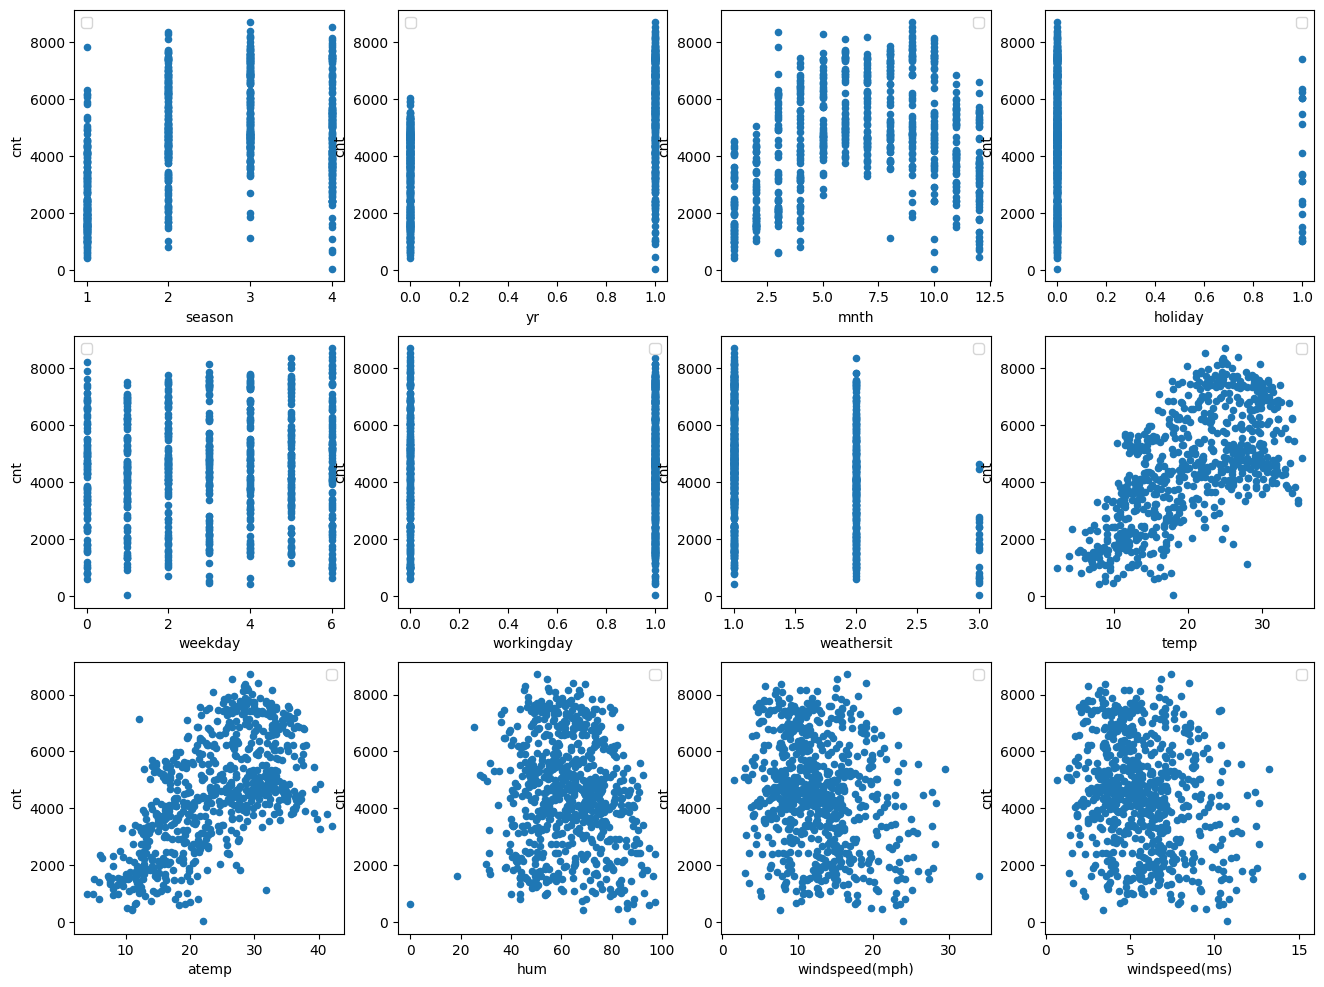

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





Ответ: Количество прокатов зависит от сезона - больше прокатов в тёплые месяцы (весна-лето), меньше в холодные (зима)

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ: temp (температура) и atemp (ощущаемая температура) - чем теплее, тем больше прокатов

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



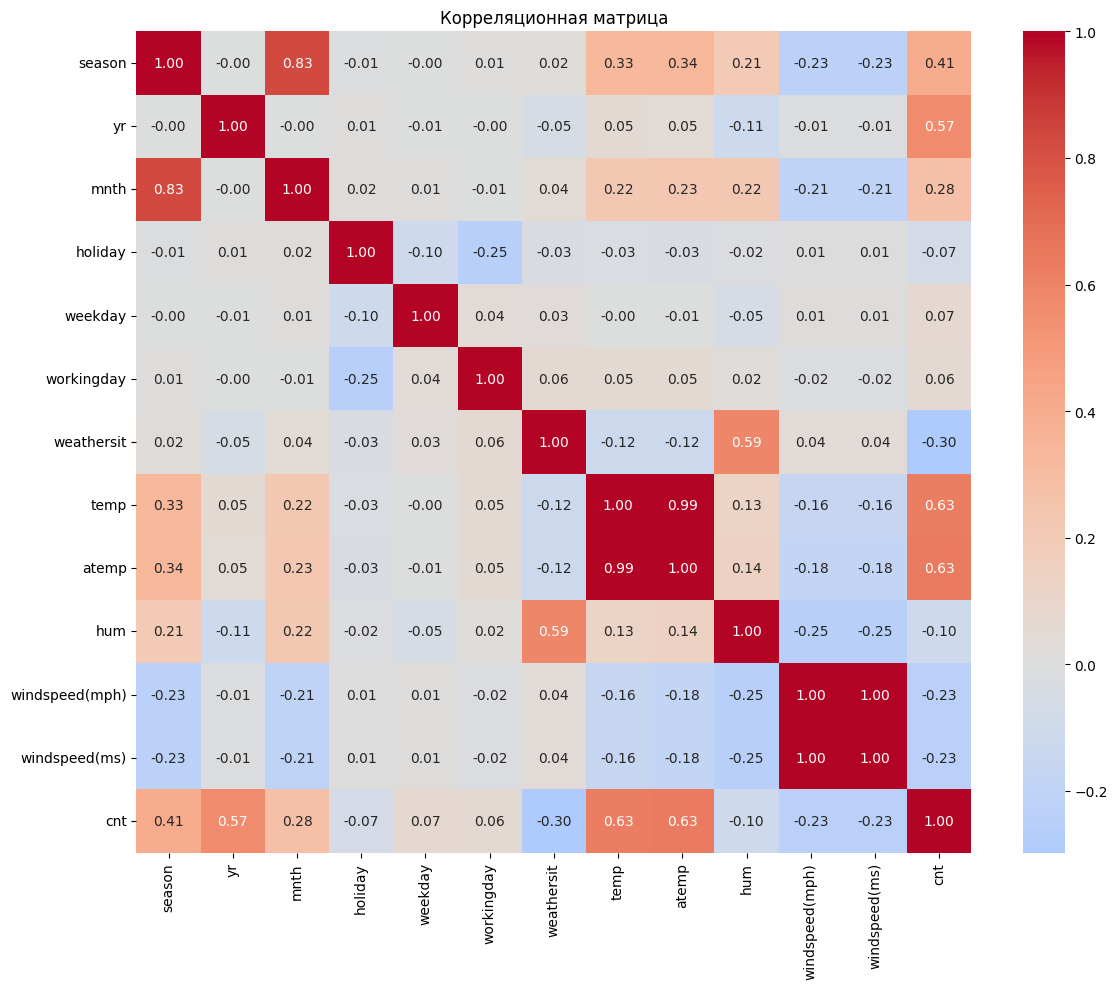

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()


**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

Ответ
Меньше всего: holiday, weekday, windspeed(mph), windspeed(ms)
Больше всего: temp, atemp, yr, hum

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



<Axes: xlabel='yr,mnth'>

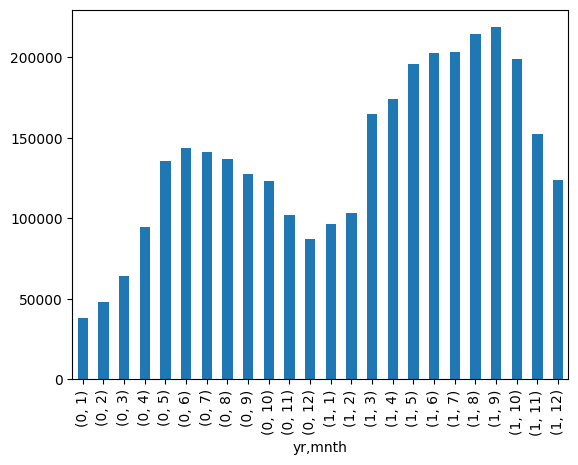

In [ ]:
df.groupby(['yr', 'mnth'])['cnt'].sum().plot(kind='bar')

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ: Большая корреляция с годом потому, что в 2012 году сервис стал популярнее, больше людей узнали о нём, увеличилось количество пользователей

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



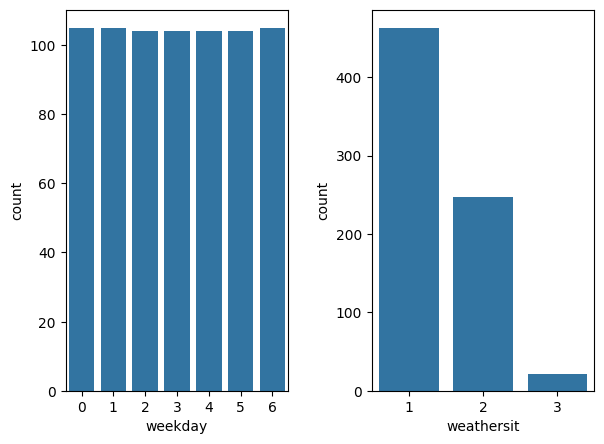

In [ ]:
fig, axs = plt.subplots(1, 2)
sns.countplot(data=df, x='weekday', ax=axs[0])
sns.countplot(data=df, x='weathersit', ax=axs[1])
fig.tight_layout(pad=2.0)
plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ:Датасет формировался равномерно - примерно одинаковое количество записей для каждого дня недели и погодных условий.

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?


    
Ответ: Равномерное распределение (uniform distribution)

### 5. Распределение

Постройте распределение целевого признака.


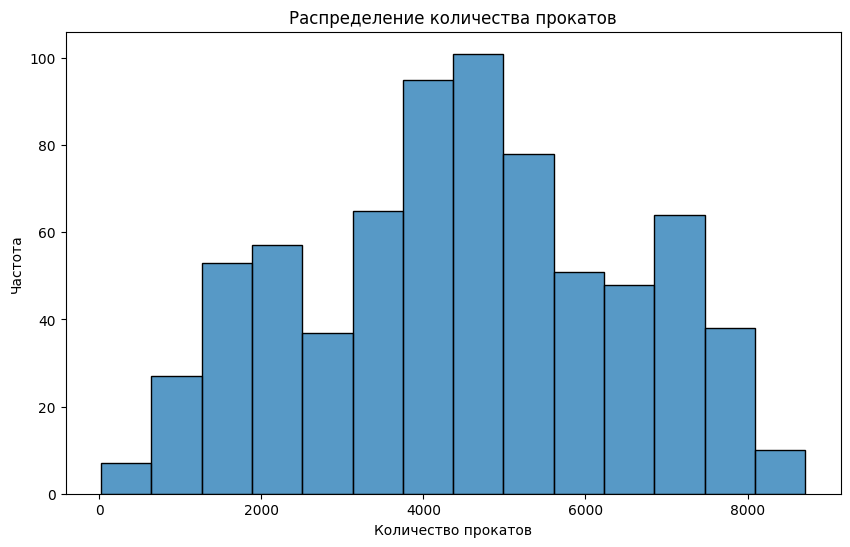

Среднее количество прокатов в день: 4504
Медиана: 4548


In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['cnt'])
plt.title('Распределение количества прокатов')
plt.xlabel('Количество прокатов')
plt.ylabel('Частота')
plt.show()

print(f"Среднее количество прокатов в день: {df['cnt'].mean():.0f}")
print(f"Медиана: {df['cnt'].median():.0f}")


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ: В среднем примерно 4500 прокатов в день.

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



<Figure size 1000x800 with 0 Axes>

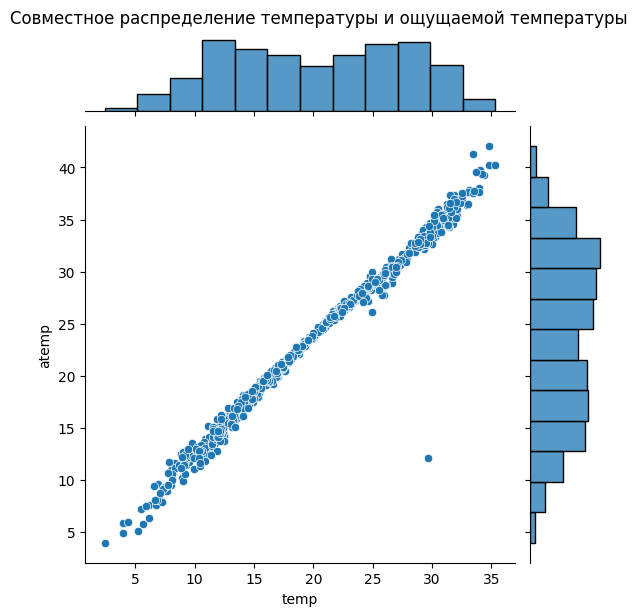

In [11]:
plt.figure(figsize=(10, 8))
sns.jointplot(x='temp', y='atemp', data=df, kind='scatter')
plt.suptitle('Совместное распределение температуры и ощущаемой температуры', y=1.02)
plt.show()

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ: Да, настораживает. Признаки temp и atemp имеют очень сильную корреляцию (почти линейная зависимость).Они практически дублируют друг друга. Для модели лучше использовать только один из них.

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




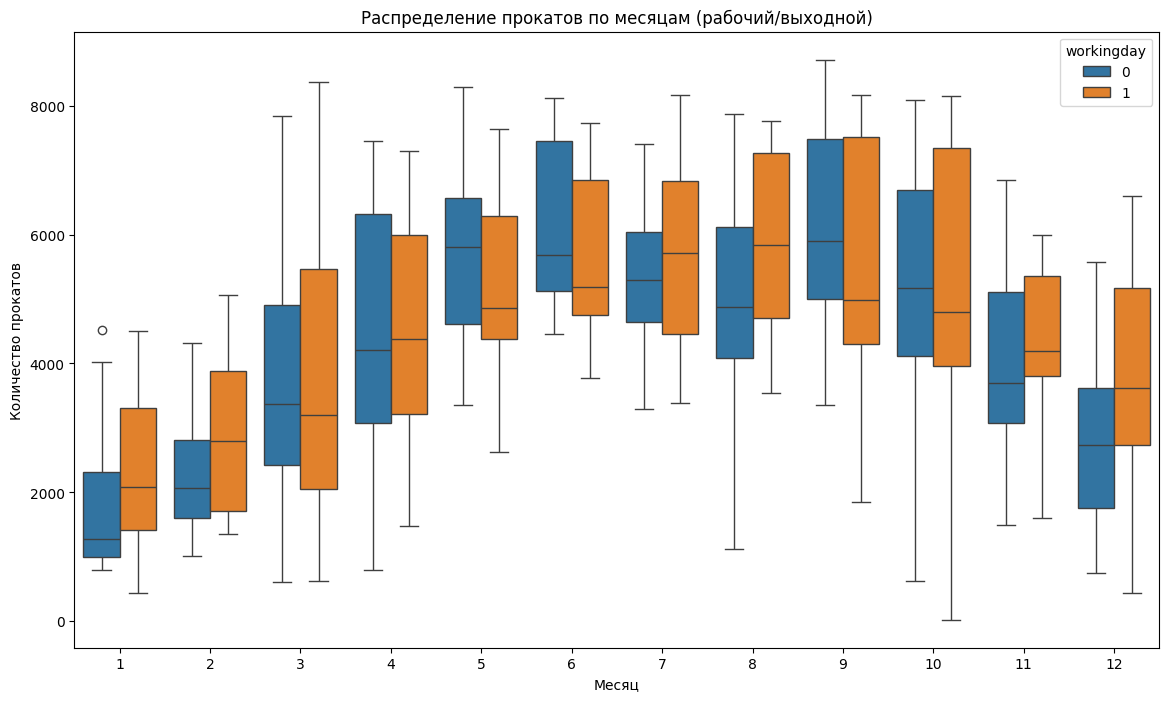

In [13]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='mnth', y='cnt', hue='workingday', data=df)
plt.title('Распределение прокатов по месяцам (рабочий/выходной)')
plt.xlabel('Месяц')
plt.ylabel('Количество прокатов')
plt.show()

**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ: В тёплые месяцы (лето) в рабочие дни прокатов больше (люди ездят на работу на велосипедах). В холодные месяцы и в выходные летом больше прокатов для отдыха и прогулок.


## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Pandas version: {pd.__version__}")

Seaborn version: 0.13.2
Matplotlib version: 3.10.0
Pandas version: 2.2.2


In [ ]:
colab = True # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [16]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')

df.head()

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


math median: 66.0
writing median: 69.0
reading median: 70.0


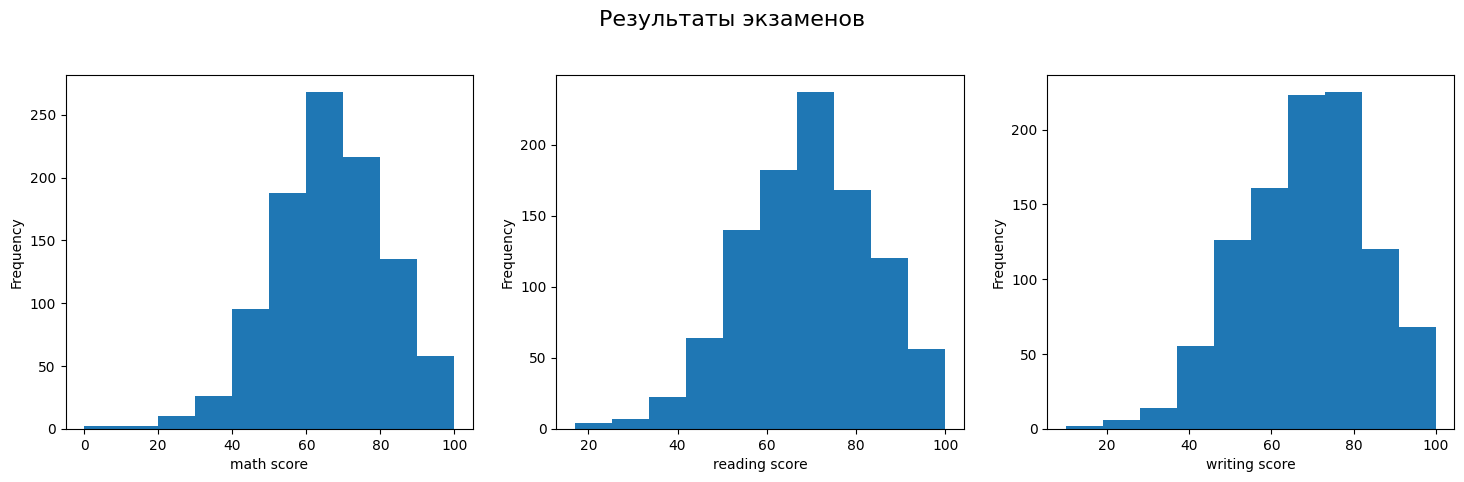

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
df['math score'].plot(kind='hist', ax=ax[0], xlabel='math score')
df['reading score'].plot(kind='hist', ax=ax[1], xlabel='reading score')
df['writing score'].plot(kind='hist', ax=ax[2], xlabel='writing score')
fig.suptitle('Результаты экзаменов', fontsize = 16)
fig.tight_layout(pad=2.0)

print(f"math median: {df['math score'].agg('median')}")
print(f"writing median: {df['writing score'].agg('median')}")
print(f"reading median: {df['reading score'].agg('median')}")
plt.show()

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


Уровни образования родителей:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


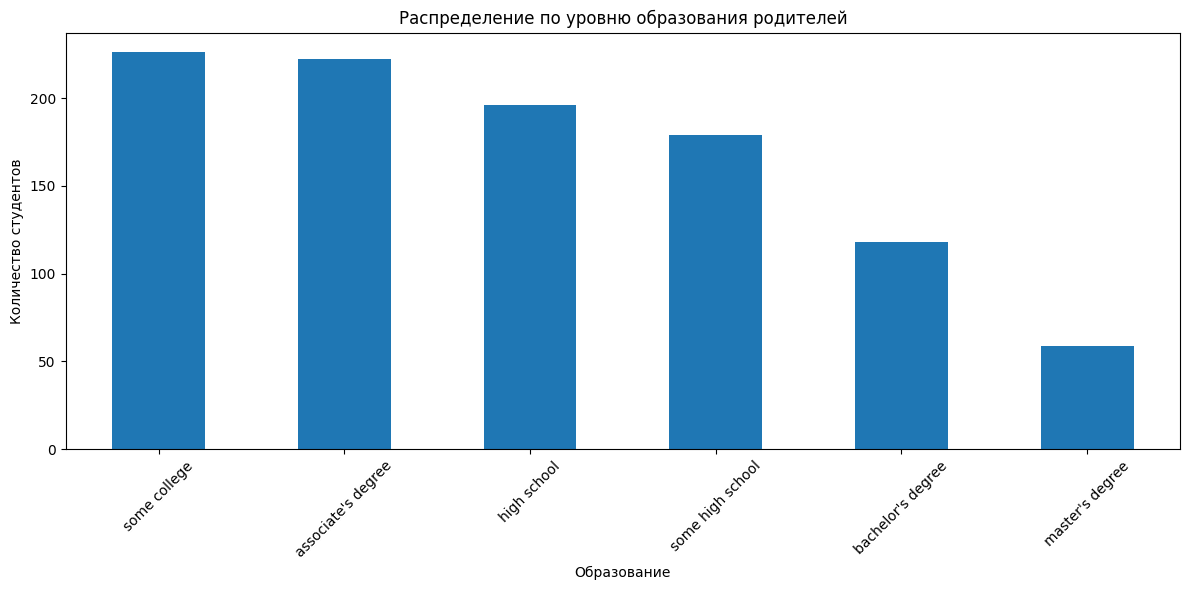

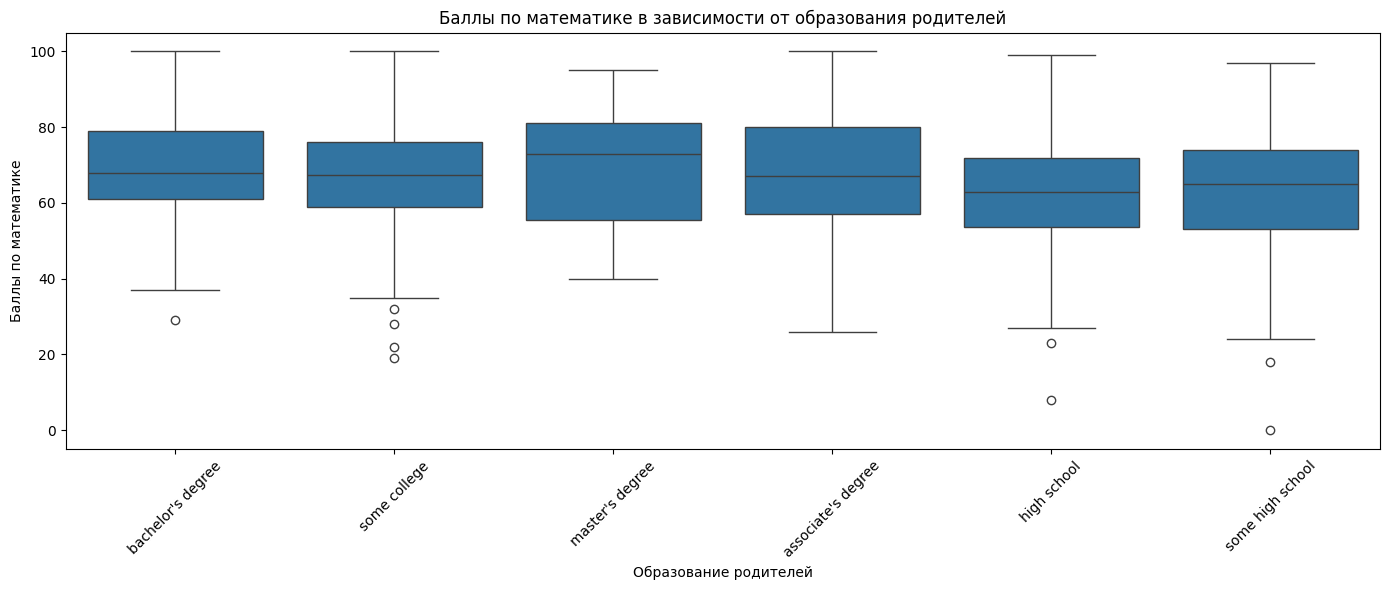

In [19]:
# Какие уровни образования есть
print("Уровни образования родителей:")
print(df['parental level of education'].value_counts())

# График
plt.figure(figsize=(12, 6))
df['parental level of education'].value_counts().plot(kind='bar')
plt.title('Распределение по уровню образования родителей')
plt.xlabel('Образование')
plt.ylabel('Количество студентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Баллы по математике в зависимости от образования родителей
plt.figure(figsize=(14, 6))
sns.boxplot(x='parental level of education', y='math score', data=df)
plt.title('Баллы по математике в зависимости от образования родителей')
plt.xlabel('Образование родителей')
plt.ylabel('Баллы по математике')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ответ: Да, баллы отличаются. Студенты, чьи родители имеют высшее образование (bachelor's, master's), в среднем показывают лучшие результаты по математике.

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [20]:
high_performing_females = df[(df['gender'] == 'female') &
                              (df['math score'] > 90) &
                              (df['reading score'] > 90) &
                              (df['writing score'] > 90)]

print(f"Количество студенток с баллами >90 по всем предметам: {len(high_performing_females)}")

Количество студенток с баллами >90 по всем предметам: 17


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [22]:
#суммарный балл
df['sum score'] = df['math score'] + df['writing score'] + df['reading score']

print("\n Суммарный балл:")
print("-" * 30)
print(df.groupby('gender')['sum score'].agg(['min', 'max', 'median']))

print("\n Математика:")
print("-" * 30)
print(df.groupby('gender')['math score'].agg(['min', 'max', 'median']))


print("\n Письмо:")
print("-" * 30)
print(df.groupby('gender')['writing score'].agg(['min', 'max', 'median']))

print("\n Чтение:")
print("-" * 30)
print(df.groupby('gender')['reading score'].agg(['min', 'max', 'median']))


 Суммарный балл:
------------------------------
        min  max  median
gender                  
female   27  300   211.0
male     69  300   199.0

 Математика:
------------------------------
        min  max  median
gender                  
female    0  100    65.0
male     27  100    69.0

 Письмо:
------------------------------
        min  max  median
gender                  
female   10  100    74.0
male     15  100    64.0

 Чтение:
------------------------------
        min  max  median
gender                  
female   17  100    73.0
male     23  100    66.0


#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

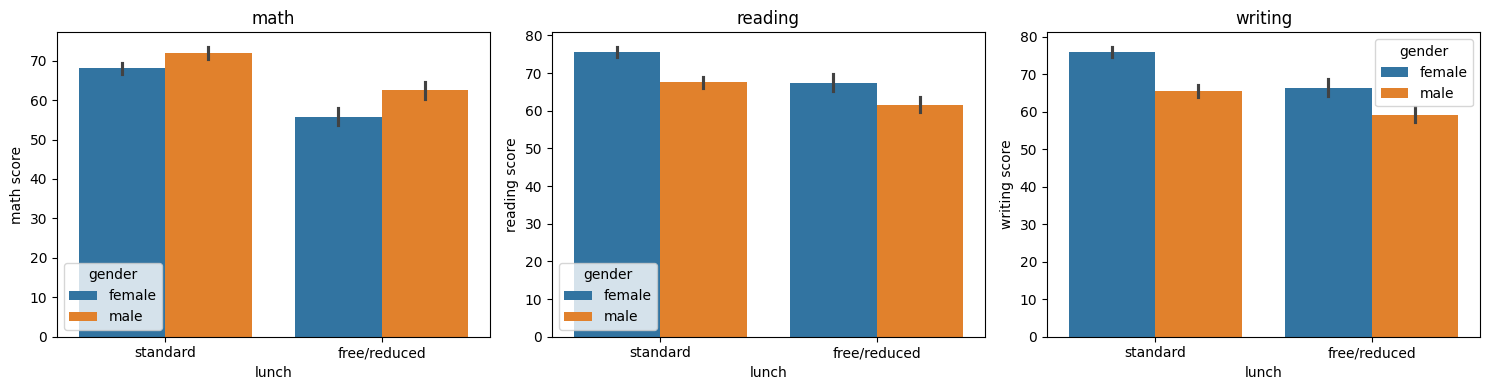

In [29]:

df.groupby(['gender', 'lunch'])[['math score', 'reading score', 'writing score']].mean()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['math score', 'reading score', 'writing score']):
    sns.barplot(data=df, x='lunch', y=col, hue='gender', ax=ax)
    ax.set_title(col.split()[0])
plt.tight_layout()
plt.show()

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

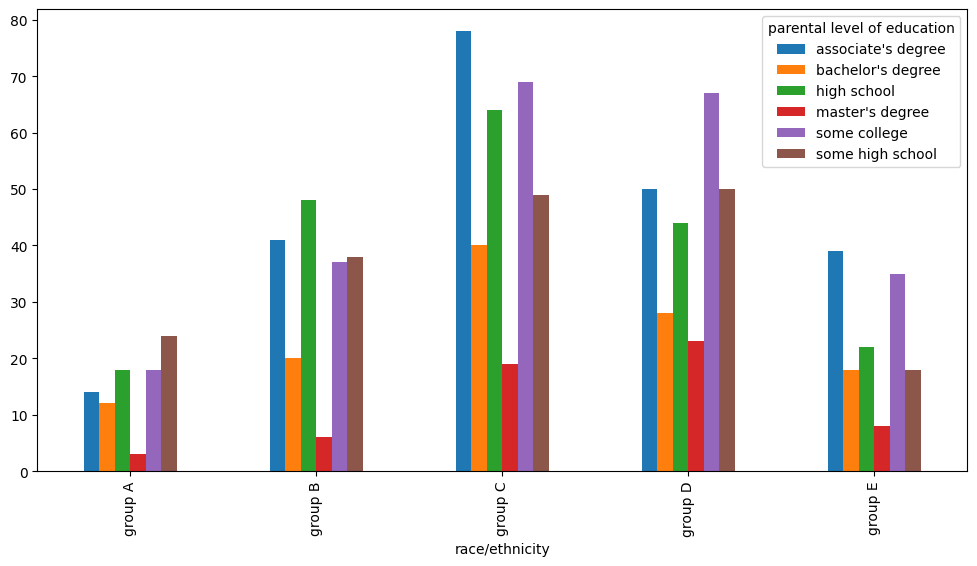

In [30]:
pd.crosstab(df['race/ethnicity'], df['parental level of education']).plot(kind='bar', figsize=(12, 6))
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

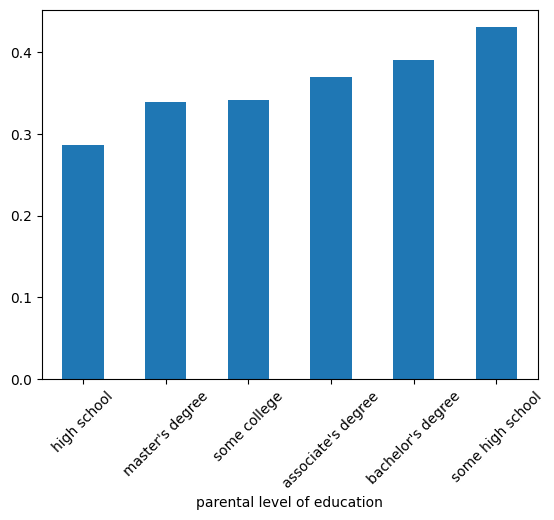

In [31]:
import matplotlib.pyplot as plt

df['test completion'] = df['test preparation course'] == 'completed'
result = df.groupby('parental level of education')['test completion'].mean().sort_values()
result.plot(kind='bar')
plt.xticks(rotation=45)
plt.show()


ответ: Дети, чьи родители имеют степень бакалавра/магистра, чаще ходят на подготовительные курсы.

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

math pass
True     960
False     40
Name: count, dtype: int64


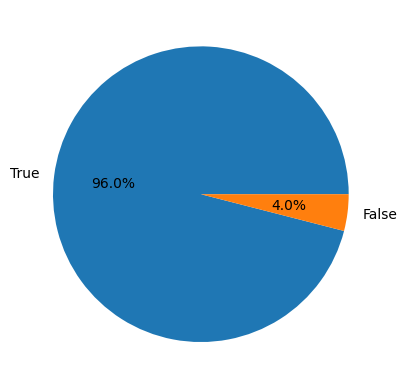

In [33]:

df['math pass'] = df['math score'] >= 40
print(df['math pass'].value_counts())
plt.pie(df['math pass'].value_counts(), labels=df['math pass'].unique(), autopct='%1.1f%%')
plt.show()

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

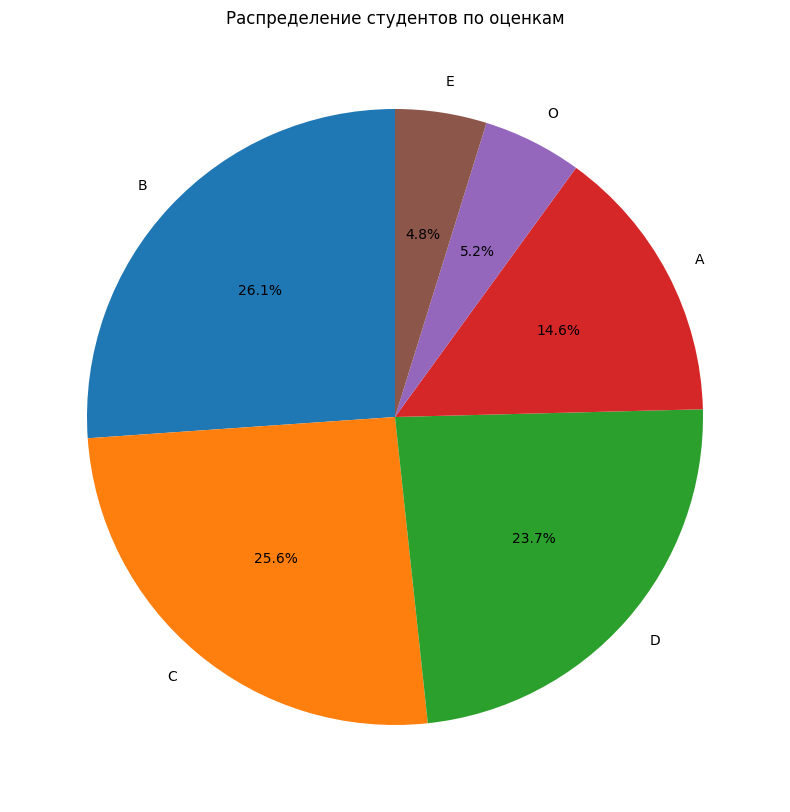

grade
B    261
C    256
D    237
A    146
O     52
E     48
Name: count, dtype: int64


In [34]:

def get_grade(row):
    if row['math score'] < 40:
        return 'E'
    avg = (row['math score'] + row['reading score'] + row['writing score']) / 3
    if avg >= 90:
        return 'O'
    elif avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 41:
        return 'D'
    else:
        return 'E'

df['grade'] = df.apply(get_grade, axis=1)

plt.figure(figsize=(10, 10))
df['grade'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение студентов по оценкам')
plt.ylabel('')
plt.show()

print(df['grade'].value_counts())

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

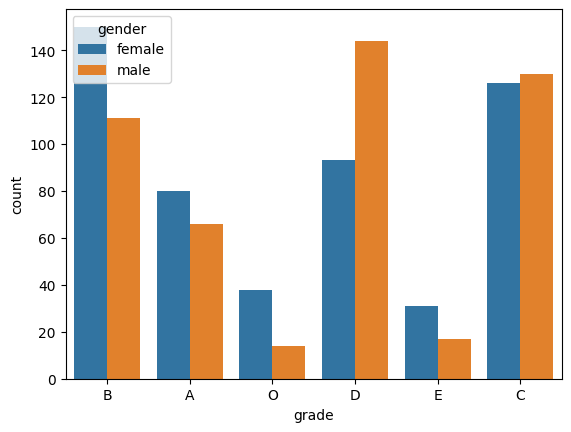

In [35]:
sns.countplot(df, x='grade', hue='gender')
plt.show()